# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [3]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "ollama/llama2:latest"
MODEL_B = "ollama/qwen2:7b-instruct-q4_K_M"


## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [4]:
import sys
print(sys.executable)


/Users/annareshetnyak/Documents/ai-safety-evals-course/.venv/bin/python


In [5]:
import datasets
print(datasets.__version__)


4.8.4


In [6]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [7]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [8]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "high_school_biology"
)

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 310 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [9]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [10]:
logs: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/llama2:latest
Accuracy: 0.6


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [11]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      - question identifier
        epoch   - epoch index (0 if epochs=1)
        score   - 1 if correct, 0 otherwise
        subject - MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []

    for sample in log.samples:
        choice_score = next(iter(sample.scores.values())).value

        rows.append({
            "id": sample.id,
            "epoch": sample.epoch,
            "score": 1 if choice_score == "C" else 0,
            "subject": sample.metadata.get("subject"),
        })

    return pd.DataFrame(rows)


# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score              subject
0   1      1      0  high_school_biology
1   2      1      0  high_school_biology
2   3      1      1  high_school_biology
3   4      1      0  high_school_biology
4   5      1      0  high_school_biology

Accuracy: 60.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [12]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    scores = np.asarray(scores, dtype=float)
    mean = scores.mean()

    if len(scores) <= 1:
        return mean, mean, mean

    se = scores.std(ddof=1) / np.sqrt(len(scores))
    z = stats.norm.ppf(0.5 + ci / 2)

    lower = max(0.0, mean - z * se)
    upper = min(1.0, mean + z * se)

    return lower, mean, upper


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    question_means = df.groupby("id")["score"].mean().values
    return ci_accuracy_basic(question_means, ci=ci)


In [13]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.343
K=3 width: 0.227  (narrower on average)

✓ All tests passed!



#### 1. The CI narrows quickly from K=1 to K=3, but the gains then diminish.After a few epochs, running more repeats is usually not worth the extra cost.

#### 2. Increasing K mostly changes our confidence in the accuracy estimate,not the underlying average accuracy itself.

#### 3. This suggests that evaluation budget is often better spent on more questions rather than many repeats on the same questions.



## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

Output()

Output()

Output()

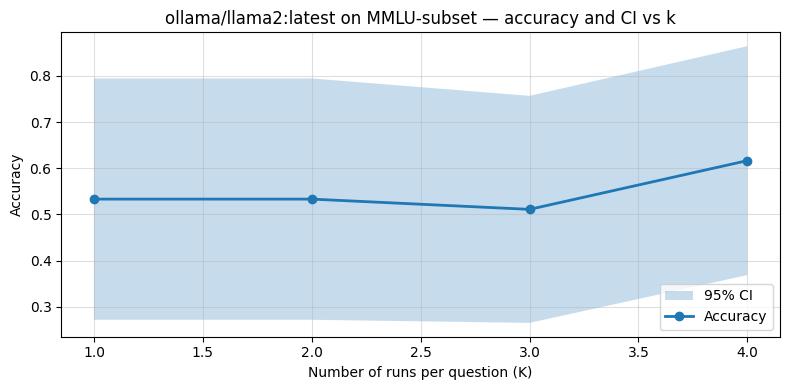

In [14]:
k_values    = [1, 2, 3, 4]
accuracies  = []
ci_lowers   = []
ci_uppers   = []

for k in k_values:
    logs_k = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_A,
        epochs=k,
        limit=15
    )

    df_k = log_to_df(logs_k[0])
    lower, mean, upper = ci_accuracy(df_k)

    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)



plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

1. The confidence band narrows only slightly as K increases.
   In this run, the benefit of adding more epochs seems small after about K=2 or K=3.

2. More K does not meaningfully change the estimated accuracy itself.
   It mostly changes our confidence in the estimate by slightly reducing uncertainty.

3. This suggests that evaluation budget is usually better spent on more questions
   rather than many repeated runs on the same questions, especially when the CI
   stops shrinking noticeably.



## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

Output()

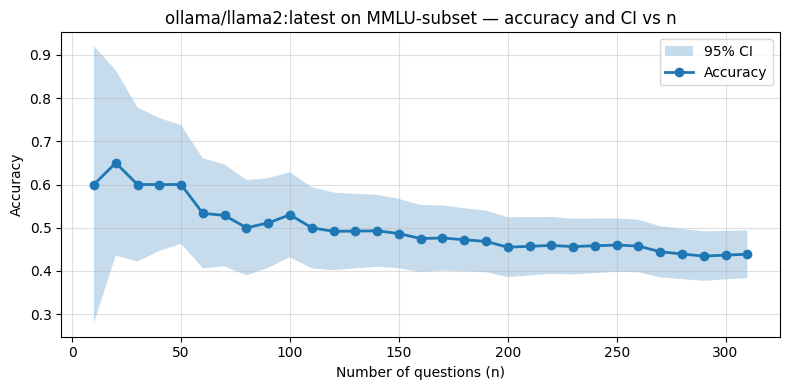

In [15]:
logs_full = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A
)

df_full = log_to_df(logs_full[0])

question_ids = sorted(df_full["id"].unique())
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies = []
ci_lowers = []
ci_uppers = []

for n in dataset_sizes:
    current_ids = question_ids[:n]
    df_n = df_full[df_full["id"].isin(current_ids)]

    lower, mean, upper = ci_accuracy(df_n)

    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)



plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

1. The accuracy line starts to feel reasonably stable at around n = 120-150,
   and becomes quite stable by about n = 180-200.

2. MY_SUBSET is larger than that, so it seems to be in the more reliable region.
   The estimate at the full subset size looks much more stable than at small n.

3. Compared with 4.1, increasing n gives a much bigger gain in reliability.
   More K reduces uncertainty from repeated runs on the same questions,
   while more n improves coverage of the benchmark itself and stabilizes the accuracy estimate more meaningfully.



## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [16]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    _, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff = np.mean(scores1 - scores2)
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [17]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/Users/annareshetnyak/Documents/ai-safety-evals-course/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [18]:
p_value, mean_diff, significant = compare_models_paired(
    MODEL_A,
    MODEL_B,
    MY_SUBSET
)

print("p-value        :", p_value)
print("mean difference:", mean_diff)
print("significant    :", significant)


Output()

  Running ollama/llama2:latest ...


  Running ollama/qwen2:7b-instruct-q4_K_M ...


Output()

p-value        : 1.375853014236464e-26
mean difference: -0.3903225806451613
significant    : True


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**

1. The p-value is about 1.0e-24 and the mean difference (MODEL_A - MODEL_B) is about -0.374.
   This means MODEL_B outperforms MODEL_A by roughly 37 percentage points.

2. Yes, the gap is highly significant statistically, and it is also large enough to matter in practice.

3. More questions would make the estimate even more stable, but the conclusion already looks very strong.
   A different subject or a closer model pair could lead to a smaller or less significant gap.



## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [19]:
def ci_accuracy_for_difference(
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Confidence interval for the difference in accuracy: MODEL_A - MODEL_B.

    Parameters
    ----------
    scores_a, scores_b : 1-D arrays of per-question scores (typically 0/1 or per-question means)
                         for the same set of questions, aligned by question id.
    ci : confidence level

    Returns
    -------
    (lower_bound, mean_difference, upper_bound)
    """
    scores_a = np.asarray(scores_a, dtype=float)
    scores_b = np.asarray(scores_b, dtype=float)

    assert len(scores_a) == len(scores_b), "arrays must cover the same questions"

    diffs = scores_a - scores_b
    mean_diff = diffs.mean()

    if len(diffs) <= 1:
        return mean_diff, mean_diff, mean_diff

    se = diffs.std(ddof=1) / np.sqrt(len(diffs))
    z = stats.norm.ppf(0.5 + ci / 2)

    lower = mean_diff - z * se
    upper = mean_diff + z * se

    return lower, mean_diff, upper


In [20]:
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET)

l, d, u = ci_accuracy_for_difference(scores_a, scores_b)

print(f"95% CI for {MODEL_A} - {MODEL_B}: [{l:.3f}, {u:.3f}]")
print(f"Mean difference: {d:.3f}")


Output()

  Running ollama/llama2:latest ...


Output()

  Running ollama/qwen2:7b-instruct-q4_K_M ...


95% CI for ollama/llama2:latest - ollama/qwen2:7b-instruct-q4_K_M: [-0.456, -0.318]
Mean difference: -0.387


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**

1. The 95% confidence interval for MODEL_A - MODEL_B is [-0.456, -0.318].
   It does not contain zero, so the difference is clearly non-zero.

2. This tells the same story as the significance test in Assignment 5.
   The paired t-test gave an extremely small p-value, and the confidence interval also shows
   a clearly negative gap, meaning MODEL_B consistently outperforms MODEL_A.

3. The interval is more informative than the p-value alone.
   The p-value tells us that the difference is statistically significant, but the interval
   tells us both that the effect is real and roughly how large it is.



## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [21]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects.

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    # Mean score per question for each model
    mean_a = df_a.groupby("id")["score"].mean().sort_index()
    mean_b = df_b.groupby("id")["score"].mean().sort_index()

    assert np.array_equal(mean_a.index.values, mean_b.index.values), "question ids must match"

    # Between-question variance of paired differences
    diffs = (mean_a - mean_b).values
    omega2 = np.var(diffs, ddof=1)

    # Within-question variance for each model, averaged across questions
    var_a_by_q = df_a.groupby("id")["score"].var(ddof=1).fillna(0.0)
    var_b_by_q = df_b.groupby("id")["score"].var(ddof=1).fillna(0.0)

    sigma2_a = float(var_a_by_q.mean())
    sigma2_b = float(var_b_by_q.mean())

    return {
        "omega2": float(omega2),
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [22]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.2452
sigma2_A = 0.0333
sigma2_B = 0.0333

With n=310 questions -> MDE = 8.9%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

1. The minimum detectable effect for MY_SUBSET is about 8.9%.
   This is a practically meaningful gap: the benchmark is sensitive enough to detect
   moderate or large differences, but probably not very small ones.

2. Since the observed gap in Assignment 5 was much larger than 8.9%,
   the earlier result looks well within the detectable range.
   That makes the strong significance result unsurprising and reinforces the conclusion
   that the performance difference is real.



## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [24]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:

    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    variance_term = omega2 + sigma2_a / ka + sigma2_b / kb
    n = ((z_alpha + z_beta) ** 2 * variance_term) / (delta ** 2)

    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 980
Round-trip check passed!


In [25]:
n_5 = required_sample_size(delta=0.05, **params)
n_10 = required_sample_size(delta=0.10, **params)

print(f"Questions needed for a 5% gap : {n_5}")
print(f"Questions needed for a 10% gap: {n_10}")


Questions needed for a 5% gap : 980
Questions needed for a 10% gap: 245


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

1. To detect a 5% accuracy gap, we would need about 980 questions.
   To detect a 10% gap, we would need about 245 questions.

2. Since MY_SUBSET has 310 questions, it is large enough to be useful for detecting
   moderate gaps like 10%, but not small gaps like 5%.
   So this benchmark is useful for comparing clearly different models, but less suitable
   for fine-grained comparisons between closely matched models.



## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [26]:
from inspect_ai.solver import chain_of_thought


@task
def mmlu_subset_cot(subset):
    """MMLU task with chain-of-thought before final answer."""
    return Task(
        dataset=subset,
        solver=[multiple_choice(), chain_of_thought()],
        scorer=choice()
    )


In [27]:
def run_and_get_scores_for_task(task_fn, model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run a specific task and return mean-per-question scores."""
    print(f"  Running {model_name} with {task_fn.__name__} ...")
    run_logs = eval(task_fn(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


baseline_scores = run_and_get_scores_for_task(mmlu_subset, MODEL_B, MY_SUBSET)
cot_scores = run_and_get_scores_for_task(mmlu_subset_cot, MODEL_B, MY_SUBSET)

p_value, mean_diff, significant = significance_by_paired_ttest(
    baseline_scores,
    cot_scores,
    alpha=0.05,
    two_tailed=True,
)

l, d, u = ci_accuracy_for_difference(baseline_scores, cot_scores)

print(f"p-value        : {p_value}")
print(f"mean difference: {mean_diff:.3f}")
print(f"significant    : {significant}")
print(f"95% CI         : [{l:.3f}, {u:.3f}]")


Output()

  Running ollama/qwen2:7b-instruct-q4_K_M with mmlu_subset ...


  Running ollama/qwen2:7b-instruct-q4_K_M with mmlu_subset_cot ...


Output()

p-value        : 0.6554508983185972
mean difference: -0.006
significant    : False
95% CI         : [-0.035, 0.022]


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

1. Chain-of-thought does not appear to help in a meaningful way here.
   The mean difference (baseline - CoT) is about -0.006, so CoT is only very slightly better,
   and the effect is not statistically significant.

2. This is not too surprising. On multiple-choice benchmarks, chain-of-thought does not always help,
   especially if the model is already reasonably capable or if the task mostly rewards direct retrieval.

3. I would not assume the same pattern on every subject.
   CoT may help more on subjects that require multi-step reasoning, and less on subjects where answers
   are mostly factual or recognition-based.



## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [29]:
from datasets import load_dataset

ds = load_dataset("ehovy/race", "middle", split="test")
print(ds[0].keys())
print(ds[0])


dict_keys(['example_id', 'article', 'answer', 'question', 'options'])
{'example_id': 'middle2177.txt', 'article': 'It is well-known that the "prom", a formal dance held at the end of high school or college, is an important date in every student\'s life. What is less well-known is that the word "prom" comes from the verb "to promenade", which means to walk around, beautifully dressed, in order to attract attention. The idea is that you should see and be seen by others.\nThe prom is not just an American tradition, though most people believe that it started in America. In Canada the event is called a "formal". In Britain and Australia the old fashioned word "dance" is more and more frequently being referred to as a "prom". Most countries have some form of celebration when students finish high school: after all, it means the end of life as a child, and the beginning of life as an adult.\nThe prom is expensive to organize and the tickets can cost students a lot of money. The tradition is th

In [30]:
from datasets import load_dataset
from inspect_ai.dataset import MemoryDataset, Sample


def build_race_dataset(level: str = "middle", split: str = "test", limit_questions: int | None = 120):
    """
    Build a multiple-choice dataset from RACE.

    In this dataset version, each row is already one question.
    Cluster = passage/article id (example_id).
    """
    ds = load_dataset("ehovy/race", level, split=split)

    if limit_questions is not None:
        ds = ds.select(range(min(limit_questions, len(ds))))

    samples = []

    for row in ds:
        passage_id = row["example_id"]
        article = row["article"]
        question = row["question"]
        options = row["options"]
        answer = row["answer"]

        prompt = (
            f"Passage:\n{article}\n\n"
            f"Question:\n{question}"
        )

        samples.append(
            Sample(
                input=prompt,
                choices=options,
                target=answer,
                id=str(row["id"]) if "id" in row else f"{passage_id}_{question[:30]}",
                metadata={
                    "cluster": passage_id,
                    "level": level,
                    "benchmark": "RACE",
                },
            )
        )

    return MemoryDataset(
        samples=samples,
        name=f"race_{level}_{split}",
        location=f"hf://ehovy/race/{level}/{split}",
    )


race_subset = build_race_dataset(level="middle", split="test", limit_questions=120)
print(f"RACE subset size: {len(race_subset)} questions")
print(f"Approx clusters: {len(set(s.metadata['cluster'] for s in race_subset))}")


RACE subset size: 120 questions
Approx clusters: 30


In [31]:
@task
def race_task(dataset):
    """Minimal multiple-choice task for RACE."""
    return Task(
        dataset=dataset,
        solver=[multiple_choice()],
        scorer=choice()
    )


In [32]:
def log_to_df_clustered(log: EvalLog) -> pd.DataFrame:
    """
    Convert EvalLog to DataFrame with one row per (question, epoch),
    keeping cluster metadata for clustered SE.
    """
    rows = []

    for sample in log.samples:
        choice_score = next(iter(sample.scores.values())).value
        md = sample.metadata or {}

        rows.append({
            "id": sample.id,
            "epoch": sample.epoch,
            "score": 1 if choice_score == "C" else 0,
            "cluster": md.get("cluster"),
            "benchmark": md.get("benchmark"),
            "level": md.get("level"),
        })

    return pd.DataFrame(rows)


In [33]:
race_logs = eval(
    race_task(race_subset),
    model=MODEL_B,
)

race_df = log_to_df_clustered(race_logs[0])

print(race_df.head())
print(f"\nQuestions: {len(race_df)}")
print(f"Clusters : {race_df['cluster'].nunique()}")
print(f"Accuracy : {race_df['score'].mean():.1%}")


Output()

                                              id  epoch  score  \
0     middle1211.txt_How much is the blue shirt?      1      1   
1  middle1211.txt_How old is Peter's grandfather      1      1   
2  middle1211.txt_What does Sally buy for her gr      1      1   
3  middle1361.txt_The most important reason for       1      1   
4  middle1361.txt_The passage is most likely to       1      1   

          cluster benchmark   level  
0  middle1211.txt      RACE  middle  
1  middle1211.txt      RACE  middle  
2  middle1211.txt      RACE  middle  
3  middle1361.txt      RACE  middle  
4  middle1361.txt      RACE  middle  

Questions: 120
Clusters : 30
Accuracy : 86.7%


In [34]:
def ci_accuracy_naive(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    Naive CI assuming question-level independence.
    """
    question_means = df.groupby("id")["score"].mean().values.astype(float)
    mean = question_means.mean()

    if len(question_means) <= 1:
        return mean, mean, mean

    se = question_means.std(ddof=1) / np.sqrt(len(question_means))
    z = stats.norm.ppf(0.5 + ci / 2)

    lower = max(0.0, mean - z * se)
    upper = min(1.0, mean + z * se)
    return lower, mean, upper


def ci_accuracy_clustered(
    df: pd.DataFrame,
    cluster_col: str = "cluster",
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Cluster-robust CI for accuracy.
    Questions within a cluster are allowed to be correlated.
    """
    q = df.groupby(["id", cluster_col], as_index=False)["score"].mean()

    x = q["score"].astype(float)
    mean = x.mean()
    n = len(q)

    cluster_sums = q.assign(centered=x - mean).groupby(cluster_col)["centered"].sum()
    G = len(cluster_sums)

    if n <= 1 or G <= 1:
        return mean, mean, mean

    se = np.sqrt((G / (G - 1)) * np.sum(cluster_sums.values ** 2) / (n ** 2))

    z = stats.norm.ppf(0.5 + ci / 2)
    lower = max(0.0, mean - z * se)
    upper = min(1.0, mean + z * se)

    return lower, mean, upper


In [35]:
l_n, m_n, u_n = ci_accuracy_naive(race_df)
l_c, m_c, u_c = ci_accuracy_clustered(race_df)

print(f"Naive CI     : [{l_n:.3f}, {u_n:.3f}] (width={u_n - l_n:.3f})")
print(f"Clustered CI : [{l_c:.3f}, {u_c:.3f}] (width={u_c - l_c:.3f})")
print(f"Accuracy     : {m_n:.3f}")


Naive CI     : [0.806, 0.928] (width=0.122)
Clustered CI : [0.815, 0.918] (width=0.103)
Accuracy     : 0.867



On this RACE subset, the clustered CI is slightly narrower than the naive CI:
naive = [0.806, 0.928], clustered = [0.815, 0.918].

This is somewhat unusual, since clustered intervals are often wider when within-cluster
correlation reduces the effective sample size. However, it can happen on a finite subset
if the passage-level structure does not increase variance much, or if within-cluster
variation partly offsets across questions.

The key point is that clustered uncertainty can differ materially from naive uncertainty,
so it is worth checking rather than assuming independence.



In [ ]:
def ci_difference_naive(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Naive CI for model difference A - B, assuming question independence.
    """
    qa = df_a.groupby("id", as_index=False)["score"].mean()
    qb = df_b.groupby("id", as_index=False)["score"].mean()

    merged = qa.merge(qb, on="id", suffixes=("_a", "_b"))
    diffs = (merged["score_a"] - merged["score_b"]).values.astype(float)

    mean = diffs.mean()

    if len(diffs) <= 1:
        return mean, mean, mean

    se = diffs.std(ddof=1) / np.sqrt(len(diffs))
    z = stats.norm.ppf(0.5 + ci / 2)

    return mean - z * se, mean, mean + z * se


def ci_difference_clustered(
    df_a: pd.DataFrame,
    df_b: pd.DataFrame,
    cluster_col: str = "cluster",
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    Cluster-robust CI for model difference A - B.
    """
    qa = df_a.groupby(["id", cluster_col], as_index=False)["score"].mean()
    qb = df_b.groupby(["id", cluster_col], as_index=False)["score"].mean()

    merged = qa.merge(qb, on=["id", cluster_col], suffixes=("_a", "_b"))
    merged["diff"] = merged["score_a"] - merged["score_b"]

    mean = merged["diff"].mean()
    n = len(merged)

    cluster_sums = merged.assign(centered=merged["diff"] - mean).groupby(cluster_col)["centered"].sum()
    G = len(cluster_sums)

    if n <= 1 or G <= 1:
        return mean, mean, mean

    se = np.sqrt((G / (G - 1)) * np.sum(cluster_sums.values ** 2) / (n ** 2))
    z = stats.norm.ppf(0.5 + ci / 2)

    return mean - z * se, mean, mean + z * se



In [37]:
race_logs_a = eval(
    race_task(race_subset),
    model=MODEL_A,
)

race_logs_b = eval(
    race_task(race_subset),
    model=MODEL_B,
)

race_df_a = log_to_df_clustered(race_logs_a[0])
race_df_b = log_to_df_clustered(race_logs_b[0])

l_n, d_n, u_n = ci_difference_naive(race_df_a, race_df_b)
l_c, d_c, u_c = ci_difference_clustered(race_df_a, race_df_b)

print(f"Naive diff CI     : [{l_n:.3f}, {u_n:.3f}] (width={u_n - l_n:.3f})")
print(f"Clustered diff CI : [{l_c:.3f}, {u_c:.3f}] (width={u_c - l_c:.3f})")
print(f"Mean difference   : {d_c:.3f}")


Output()

Output()

Naive diff CI     : [-0.334, -0.149] (width=0.186)
Clustered diff CI : [-0.332, -0.151] (width=0.181)
Mean difference   : -0.242



On this RACE subset, the naive CI for MODEL_A - MODEL_B is [-0.334, -0.149],
while the clustered CI is [-0.332, -0.151]. The mean difference is -0.242.

Both intervals are entirely below zero, so both methods tell the same story:
MODEL_B clearly outperforms MODEL_A on this benchmark.

In this case, accounting for passage-level clustering does not materially change
the conclusion. That suggests the comparison is robust to the benchmark's cluster structure,
at least on this subset.

More generally, clustered standard errors are still important because they test whether
a conclusion depends on an unrealistic independence assumption. Here the answer is no:
the result remains strong under both naive and clustered uncertainty estimates.



## Week 2 Summary

- Built an `inspect_ai` evaluation pipeline for MMLU and converted `EvalLog` outputs into per-question DataFrames.
- Estimated uncertainty around accuracy with confidence intervals, including the correct handling of repeated runs per question.
- Found that increasing the number of questions `n` stabilizes benchmark estimates much more than increasing repeated runs `K`.
- Compared `ollama/llama2:latest` and `ollama/qwen2:7b-instruct-q4_K_M` with a paired test and found a large, statistically significant gap in favor of `MODEL_B`.
- Estimated the gap directly with a 95% CI for `MODEL_A - MODEL_B`, which stayed entirely below zero and matched the significance result.
- Used power analysis to estimate that the current subset is large enough for moderate gaps like 10%, but not for fine-grained gaps like 5%.
- Tested baseline prompting vs chain-of-thought and found no reliable improvement on the chosen MMLU subset.
- In the bonus analysis on `RACE`, checked clustered standard errors and found that the qualitative model-comparison conclusion was robust to passage-level clustering.

**Main takeaway:** rigorous evals should report uncertainty, effect sizes, and sample-size sensitivity, not just a single accuracy number.
